### Investicinių portfelių sudarymas

In [ ]:
# pasirenkamos akcijos europos
akcijos = [
    "ASML.AS",   # ASML Holding
    "SAP.DE",    # SAP
    "SIE.DE",    # Siemens
    "MC.PA",     # LVMH
    "TTE.PA",    # TotalEnergies
    "AIR.PA",    # Airbus
    "SAN.PA",    # Sanofi
    "NESN.SW",   # Nestlé
    "NOVO-B.CO", # Novo Nordisk
    "SAN.MC"     # Banco Santander 
]

print(akcijos)

['ASML.AS', 'SAP.DE', 'SIE.DE', 'MC.PA', 'TTE.PA', 'AIR.PA', 'SAN.PA', 'NESN.SW', 'NOVO-B.CO', 'SAN.MC']


In [17]:
# jav akcijos
akcijos = [
    "MSFT",  # Information Technology - Microsoft
    "JPM",   # Financials - JPMorgan Chase
    "XOM",   # Energy - Exxon Mobil
    "JNJ",   # Health Care - Johnson & Johnson
    "PG",    # Consumer Staples - Procter & Gamble
    "HD",    # Consumer Discretionary - Home Depot
    "CAT",   # Industrials - Caterpillar
    "LIN",   # Materials - Linde
    "AMT",   # Real Estate - American Tower
    "GOOGL"  # Communication Services - Alphabet
]
print(akcijos)

['MSFT', 'JPM', 'XOM', 'JNJ', 'PG', 'HD', 'CAT', 'LIN', 'AMT', 'GOOGL']


In [18]:
import warnings
warnings.filterwarnings("ignore", message="Timestamp\\.utcnow is deprecated")
import yfinance as yf
import pandas as pd

pradzia = "2016-01-01"
pabaiga = "2026-01-01"
duomenys = yf.download(
    akcijos,
    start=pradzia,
    end=pabaiga,
    interval="1d",
    progress=False,
    auto_adjust=True  
)
kainos = duomenys["Close"].copy()
kainos = kainos.dropna(how="all")
kainos = kainos.ffill()
kainos = kainos.dropna()

print("Likusios akcijos:", len(kainos.columns))
print("Akcijų sąrašas:", kainos.columns.tolist())

split_index = int(len(kainos) * 0.8)
train_kainos = kainos.iloc[:split_index]
test_kainos = kainos.iloc[split_index:]
train_returns = train_kainos.pct_change().dropna()
test_returns = test_kainos.pct_change().dropna()

Likusios akcijos: 10
Akcijų sąrašas: ['AMT', 'CAT', 'GOOGL', 'HD', 'JNJ', 'JPM', 'LIN', 'MSFT', 'PG', 'XOM']


In [19]:
# skaiciuojamos dienine grazos
train_grazos = train_kainos.pct_change().dropna()
test_grazos = test_kainos.pct_change().dropna()
print("Train grąžų pirmos 5 eilutės:")
print(train_grazos.head())
print("\nTest grąžų pirmos 5 eilutės:")
print(test_grazos.head())
print("\nTrain grąžų dydis:", train_grazos.shape)
print("Test grąžų dydis:", test_grazos.shape)

#metines vidutines grazos ir kovariaciju matrica
mean_returns = train_grazos.mean() * 252
cov_matrix = train_grazos.cov() * 252
print("\nMetinės vidutinės grąžos:")
print(mean_returns)
print("\nKovariacijų matrica:")
print(cov_matrix)

Train grąžų pirmos 5 eilutės:
Ticker           AMT       CAT     GOOGL        HD       JNJ       JPM  \
Date                                                                     
2016-01-05  0.019751 -0.010443  0.002752 -0.004883  0.004180  0.001729   
2016-01-06 -0.003549 -0.015754 -0.002889 -0.010350 -0.005054 -0.014436   
2016-01-07 -0.024934 -0.034431 -0.024140 -0.028510 -0.011655 -0.040439   
2016-01-08 -0.016491 -0.010166 -0.013617 -0.011962 -0.010684 -0.022399   
2016-01-11  0.002653 -0.028756  0.002955  0.015174 -0.006010 -0.001528   

Ticker           LIN      MSFT        PG       XOM  
Date                                                
2016-01-05 -0.003443  0.004562  0.003190  0.008520  
2016-01-06 -0.010067 -0.018165 -0.009667 -0.008320  
2016-01-07 -0.025025 -0.034783 -0.008733 -0.016006  
2016-01-08  0.000614  0.003067 -0.015678 -0.020202  
2016-01-11  0.006029 -0.000573  0.009214 -0.013388  

Test grąžų pirmos 5 eilutės:
Ticker           AMT       CAT     GOOGL        HD

In [ ]:
import numpy as np
from scipy.optimize import minimize

risk_free_rate = 0.02 
num_assets = len(mean_returns)


def portfolio_performance(weights, mean_returns, cov_matrix):
    port_return = np.sum(weights * mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol


def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    port_return, port_vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(port_return - risk_free_rate) / port_vol

# svoriai 
constraints = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})

bounds = tuple((0, 1) for _ in range(num_assets))
initial_weights = np.ones(num_assets) / num_assets


# Optimizacija
opt_result = minimize(
    negative_sharpe,
    initial_weights,
    args=(mean_returns, cov_matrix, risk_free_rate),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)


optimal_weights = opt_result.x
opt_return, opt_vol = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
opt_sharpe = (opt_return - risk_free_rate) / opt_vol


print("\n=== Maksimalaus Sharpe rodiklio portfelis ===")

weights_df = pd.DataFrame({
    "Akcija": mean_returns.index,
    "Svoris": optimal_weights
})
print("\nOptimalūs svoriai:")
print(weights_df)
print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {opt_return:.4f}")
print(f"Metinė rizika (std): {opt_vol:.4f}")
print(f"Sharpe santykis: {opt_sharpe:.4f}")


=== Maksimalaus Sharpe rodiklio portfelis ===

Optimalūs svoriai:
  Akcija        Svoris
0    AMT  1.199035e-16
1    CAT  2.420086e-01
2  GOOGL  1.319793e-16
3     HD  1.819077e-17
4    JNJ  0.000000e+00
5    JPM  7.659552e-18
6    LIN  2.040753e-01
7   MSFT  5.158507e-01
8     PG  3.806544e-02
9    XOM  3.880311e-17

Portfelio rodikliai:
Metinė grąža: 0.2649
Metinė rizika (std): 0.2240
Sharpe santykis: 1.0934


In [21]:
# bandymas su testiniais duomenimis
test_mean_returns = test_grazos.mean() * 252
test_cov_matrix = test_grazos.cov() * 252
test_return, test_vol = portfolio_performance(
    optimal_weights,
    test_mean_returns,
    test_cov_matrix
)
test_sharpe = (test_return - risk_free_rate) / test_vol
print("\n=== ne imties testas ===")
print(f"Metinė grąža: {test_return:.4f}")
print(f"Metinė rizika: {test_vol:.4f}")
print(f"Sharpe santykis: {test_sharpe:.4f}")


=== ne imties testas ===
Metinė grąža: 0.1865
Metinė rizika: 0.1730
Sharpe santykis: 0.9622


In [22]:
#minimalios dispersijos portfelis
import numpy as np
from scipy.optimize import minimize
num_assets = len(mean_returns)
def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

constraints = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})
bounds = tuple((0, 1) for _ in range(num_assets))  # be short selling
initial_weights = np.ones(num_assets) / num_assets
# Optimizacija
minvar_result = minimize(
    portfolio_volatility,
    initial_weights,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

minvar_weights = minvar_result.x

# treniravimo rodikliai
minvar_return, minvar_vol = portfolio_performance(
    minvar_weights,
    mean_returns,
    cov_matrix
)

minvar_sharpe = (minvar_return - risk_free_rate) / minvar_vol

print("\n=== minimalios dispersijos portfelis treniravimui ===")

weights_df = pd.DataFrame({
    "Akcija": mean_returns.index,
    "Svoris": minvar_weights
})

print("\nOptimalūs svoriai:")
print(weights_df)

print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {minvar_return:.4f}")
print(f"Metinė rizika: {minvar_vol:.4f}")
print(f"Sharpe santykis: {minvar_sharpe:.4f}")


=== minimalios dispersijos portfelis treniravimui ===

Optimalūs svoriai:
  Akcija        Svoris
0    AMT  3.919176e-02
1    CAT  1.141695e-03
2  GOOGL  5.610103e-02
3     HD  5.027689e-02
4    JNJ  3.666003e-01
5    JPM  6.505213e-19
6    LIN  5.700812e-02
7   MSFT  1.029992e-18
8     PG  3.272316e-01
9    XOM  1.024486e-01

Portfelio rodikliai:
Metinė grąža: 0.1293
Metinė rizika: 0.1572
Sharpe santykis: 0.6953


In [23]:
# bandymas su testiniais duomenimis
test_return_mv, test_vol_mv = portfolio_performance(
    minvar_weights,
    test_grazos.mean() * 252,
    test_grazos.cov() * 252
)

test_sharpe_mv = (test_return_mv - risk_free_rate) / test_vol_mv

print("\n=== minimalios dispersijos portfelis testavimui ===")
print(f"Metinė grąža: {test_return_mv:.4f}")
print(f"Metinė rizika: {test_vol_mv:.4f}")
print(f"Sharpe santykis: {test_sharpe_mv:.4f}")


=== minimalios dispersijos portfelis testavimui ===
Metinė grąža: 0.1222
Metinė rizika: 0.1204
Sharpe santykis: 0.8495


In [24]:
#lygiasvoris portfelis

num_assets = len(mean_returns)

equal_weights = np.ones(num_assets) / num_assets

#treniravimo rodikliai
ew_return, ew_vol = portfolio_performance(equal_weights, mean_returns, cov_matrix)
ew_sharpe = (ew_return - risk_free_rate) / ew_vol

print("\n=== lygiasvoris portfelis treniravimui ===")
weights_df = pd.DataFrame({
    "Akcija": mean_returns.index,
    "Svoris": equal_weights
})
print("\nOptimalūs svoriai (lygūs):")
print(weights_df)
print("\nPortfelio rodikliai:")
print(f"Metinė grąža: {ew_return:.4f}")
print(f"Metinė rizika: {ew_vol:.4f}")
print(f"Sharpe santykis: {ew_sharpe:.4f}")

#lygiasvoris portfelis testavimui
test_ew_return, test_ew_vol = portfolio_performance(
    equal_weights,
    test_grazos.mean() * 252,
    test_grazos.cov() * 252
)
test_ew_sharpe = (test_ew_return - risk_free_rate) / test_ew_vol

print("\n=== lygiasvoris portfelis testavimui ===")
print(f"Metinė grąža: {test_ew_return:.4f}")
print(f"Metinė rizika: {test_ew_vol:.4f}")
print(f"Sharpe santykis: {test_ew_sharpe:.4f}")


=== lygiasvoris portfelis treniravimui ===

Optimalūs svoriai (lygūs):
  Akcija  Svoris
0    AMT     0.1
1    CAT     0.1
2  GOOGL     0.1
3     HD     0.1
4    JNJ     0.1
5    JPM     0.1
6    LIN     0.1
7   MSFT     0.1
8     PG     0.1
9    XOM     0.1

Portfelio rodikliai:
Metinė grąža: 0.1854
Metinė rizika: 0.1813
Sharpe santykis: 0.9124

=== lygiasvoris portfelis testavimui ===
Metinė grąža: 0.1792
Metinė rizika: 0.1197
Sharpe santykis: 1.3294


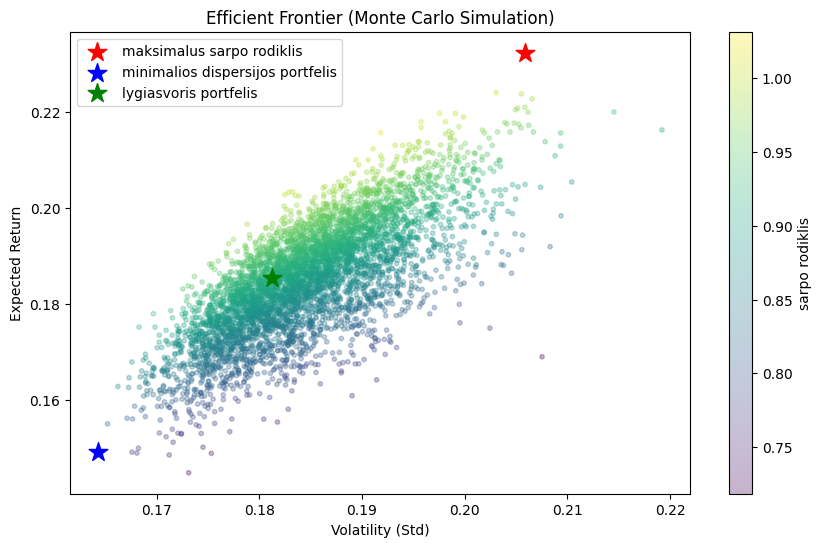

In [25]:
import matplotlib.pyplot as plt

#simuliacinis portfelis
num_portfolios = 5000

results = np.zeros((3, num_portfolios))
all_weights = []

for i in range(num_portfolios):
    # atsitiktiniai svoriai
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    all_weights.append(weights)
    port_return, port_vol = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe = (port_return - risk_free_rate) / port_vol
    results[0,i] = port_return
    results[1,i] = port_vol
    results[2,i] = sharpe

# maksimalus sarpo rodiklis iš simuliacijų
max_sharpe_idx = np.argmax(results[2])
ms_return, ms_vol, ms_sharpe = results[:, max_sharpe_idx]
ms_weights = all_weights[max_sharpe_idx]

# minimalios dispersijos portfelis iš simuliacijų
min_vol_idx = np.argmin(results[1])
mv_return, mv_vol, mv_sharpe = results[:, min_vol_idx]
mv_weights = all_weights[min_vol_idx]

# efficinet frontier grafikas
plt.figure(figsize=(10,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='sarpo rodiklis')
plt.scatter(ms_vol, ms_return, color='r', marker='*', s=200, label='maksimalus sarpo rodiklis')
plt.scatter(mv_vol, mv_return, color='b', marker='*', s=200, label='minimalios dispersijos portfelis')
plt.scatter(ew_vol, ew_return, color='g', marker='*', s=200, label='lygiasvoris portfelis')
plt.title('Efficient Frontier (Monte Carlo Simulation)')
plt.xlabel('Volatility (Std)')
plt.ylabel('Expected Return')
plt.legend()
plt.show()

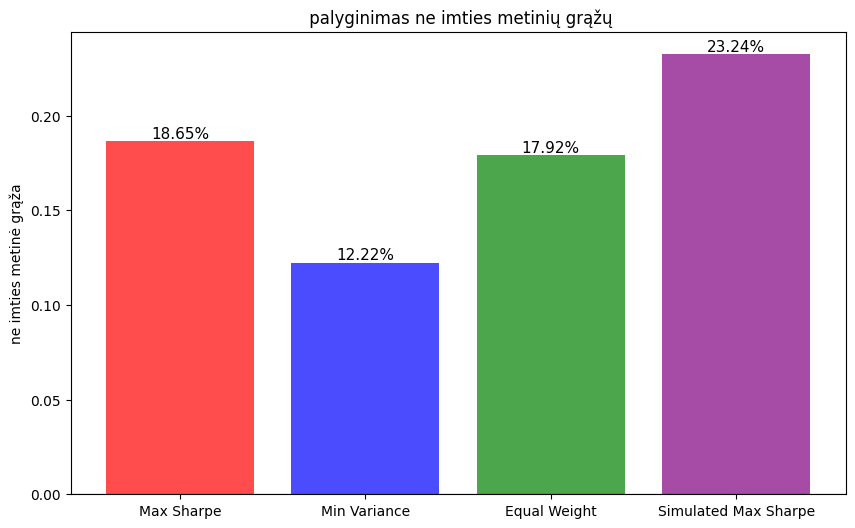

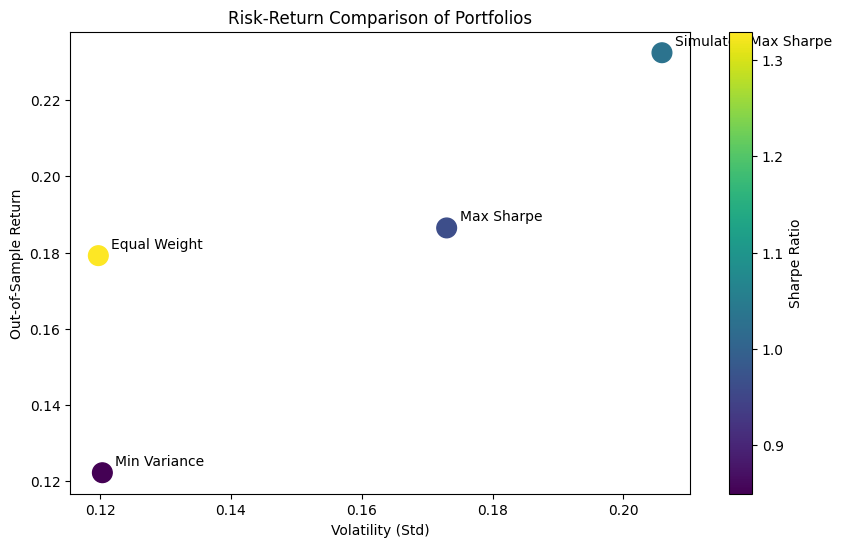

In [26]:
import matplotlib.pyplot as plt

# testavimas su visais portfeliais
portfolio_names = ['Max Sharpe', 'Min Variance', 'Equal Weight', 'Simulated Max Sharpe']
portfolio_returns = [
    test_return,          # Max Sharpe test
    test_return_mv,       # Min Variance test
    test_ew_return,       # Equal Weight test
    ms_return             # Simulated Max Sharpe (from Monte Carlo)
]

portfolio_vols = [
    test_vol,
    test_vol_mv,
    test_ew_vol,
    ms_vol
]

portfolio_sharpe = [
    test_sharpe,
    test_sharpe_mv,
    test_ew_sharpe,
    ms_sharpe
]

#grazu palyginimas
plt.figure(figsize=(10,6))
bars = plt.bar(portfolio_names, portfolio_returns, color=['red','blue','green','purple'], alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('ne imties metinė grąža')
plt.title(' palyginimas ne imties metinių grąžų')

for bar, ret in zip(bars, portfolio_returns):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{ret:.2%}', ha='center', va='bottom', fontsize=11)

plt.show()

plt.figure(figsize=(10,6))
plt.scatter(portfolio_vols, portfolio_returns, s=200, c=portfolio_sharpe, cmap='viridis')
for i, name in enumerate(portfolio_names):
    plt.text(portfolio_vols[i]+0.002, portfolio_returns[i]+0.002, name)
plt.xlabel('Volatility (Std)')
plt.ylabel('Out-of-Sample Return')
plt.title('Risk-Return Comparison of Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.show()

In [27]:
from skfolio.optimization import MaximumDiversification
import pandas as pd


X_train = train_grazos  
maxdiv_model = MaximumDiversification()
maxdiv_model.fit(X_train)
maxdiv_weights = maxdiv_model.weights_
maxdiv_df = pd.DataFrame({
    "Akcija": X_train.columns,
    "Svoris": maxdiv_weights
})
print("\n=== maksimalaus diversifikavimo portfelis train ===")
print(maxdiv_df)


mvdiv_return, mvdiv_vol = portfolio_performance(maxdiv_weights, mean_returns, cov_matrix)
mvdiv_sharpe = (mvdiv_return - risk_free_rate) / mvdiv_vol

print("\nTrain metrics:")
print(f"Return: {mvdiv_return:.4f}, Vol: {mvdiv_vol:.4f}, Sharpe: {mvdiv_sharpe:.4f}")

# bandymas su testiniais duomenimis
test_mean_returns = test_grazos.mean() * 252
test_cov_matrix = test_grazos.cov() * 252

test_mvdiv_return, test_mvdiv_vol = portfolio_performance(maxdiv_weights, test_mean_returns, test_cov_matrix)
test_mvdiv_sharpe = (test_mvdiv_return - risk_free_rate) / test_mvdiv_vol

print("\n=== maksimalaus diversifikavimo portfelis (TEST) ===")
print(f"Test Return: {test_mvdiv_return:.4f}")
print(f"Test Volatility: {test_mvdiv_vol:.4f}")
print(f"Test Sharpe: {test_mvdiv_sharpe:.4f}")


=== maksimalaus diversifikavimo portfelis train ===
  Akcija    Svoris
0    AMT  0.158801
1    CAT  0.097673
2  GOOGL  0.136019
3     HD  0.056920
4    JNJ  0.164270
5    JPM  0.013714
6    LIN  0.005439
7   MSFT  0.008790
8     PG  0.186383
9    XOM  0.171991

Train metrics:
Return: 0.1552, Vol: 0.1698, Sharpe: 0.7962

=== maksimalaus diversifikavimo portfelis (TEST) ===
Test Return: 0.1648
Test Volatility: 0.1151
Test Sharpe: 1.2585


In [28]:
from skfolio.optimization import RiskBudgeting
from skfolio.measures import RiskMeasure
import pandas as pd

#rizikos pariteto portfelis
risk_parity_model = RiskBudgeting(
    risk_measure=RiskMeasure.VARIANCE,
    portfolio_params=dict(name="Risk Parity - Variance")
)


risk_parity_model.fit(train_grazos)
rp_weights = risk_parity_model.weights_
rp_df = pd.DataFrame({
    "Akcija": train_grazos.columns,
    "Svoris": rp_weights
})

print("\n=== rizikos pariteto portfelis (TRAIN) ===")
print(rp_df)

# treniravimo rodikliai
rp_return, rp_vol = portfolio_performance(rp_weights, mean_returns, cov_matrix)
rp_sharpe = (rp_return - risk_free_rate) / rp_vol

print("\nTrain metrics:")
print(f"Return: {rp_return:.4f}")
print(f"Volatility: {rp_vol:.4f}")
print(f"Sharpe: {rp_sharpe:.4f}")

# bandymas su testiniais duomenimis
test_rp_return, test_rp_vol = portfolio_performance(
    rp_weights,
    test_grazos.mean() * 252,
    test_grazos.cov() * 252
)
test_rp_sharpe = (test_rp_return - risk_free_rate) / test_rp_vol

print("\n=== rizikos pariteto portfelis (TEST) ===")
print(f"Test Return: {test_rp_return:.4f}")
print(f"Test Volatility: {test_rp_vol:.4f}")
print(f"Test Sharpe: {test_rp_sharpe:.4f}")


=== rizikos pariteto portfelis (TRAIN) ===
  Akcija    Svoris
0    AMT  0.102612
1    CAT  0.081948
2  GOOGL  0.087466
3     HD  0.093391
4    JNJ  0.141307
5    JPM  0.082076
6    LIN  0.093873
7   MSFT  0.083505
8     PG  0.138335
9    XOM  0.095486

Train metrics:
Return: 0.1761
Volatility: 0.1743
Sharpe: 0.8953

=== rizikos pariteto portfelis (TEST) ===
Test Return: 0.1646
Test Volatility: 0.1142
Test Sharpe: 1.2661
